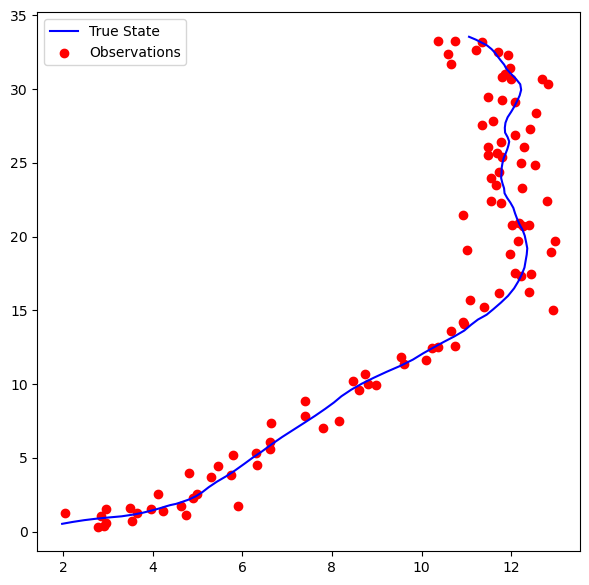

In [1]:
import numpy as np
import scipy
from collections import namedtuple
import matplotlib.pyplot as plt
import jax

jax.config.update("jax_enable_x64", True)

StateSpaceModel = namedtuple(
    "StateSpaceModel", ["F", "H", "Q", "R", "m0", "P0", "xdim", "ydim"]
)


def make_car_tracking_model(
    q: float, dt: float, r: float, m0: np.ndarray, P0: np.ndarray
):
    F = np.eye(4) + dt * np.eye(4, k=2)
    H = np.eye(2, 4)
    Q = np.kron(np.array([[dt**3 / 3, dt**2 / 2], [dt**2 / 2, dt]]), np.eye(2))
    R = r**2 * np.eye(2)
    return StateSpaceModel(F, H, q * Q, R, m0, P0, m0.shape[0], H.shape[0])


car_tracking_model = make_car_tracking_model(
    q=1.0, dt=0.1, r=0.5, m0=np.array([0.0, 0.0, 1.0, -1.0]), P0=np.eye(4)
)


def get_data(model: StateSpaceModel, T: float, seed: int = 0):
    # We first generate the normals we will be using to simulate the SSM:
    rng = np.random.RandomState(seed)
    normals = rng.randn(1 + T, model.xdim + model.ydim)

    # Then we allocate the arrays where the simulated path and observations will
    # be stored:
    xs = np.empty((T, model.xdim))
    ys = np.empty((T, model.ydim))

    # So that we can now run the sampling routine:
    Q_chol = scipy.linalg.cholesky(model.Q, lower=True)
    R_chol = scipy.linalg.cholesky(model.R, lower=True)
    P0_chol = scipy.linalg.cholesky(model.P0, lower=True)
    x = model.m0 + P0_chol @ normals[0, : model.xdim]
    for i, norm in enumerate(normals[1:]):
        x = model.F @ x + Q_chol @ norm[: model.xdim]
        y = model.H @ x + R_chol @ norm[model.xdim :]
        xs[i] = x
        ys[i] = y
    return xs, ys


log10T = 4


true_xs, ys = get_data(car_tracking_model, 10**log10T, 0)


fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(true_xs[:100, 0], true_xs[:100, 1], label="True State", color="b")
ax.scatter(*ys[:100].T, label="Observations", color="r")
_ = plt.legend()

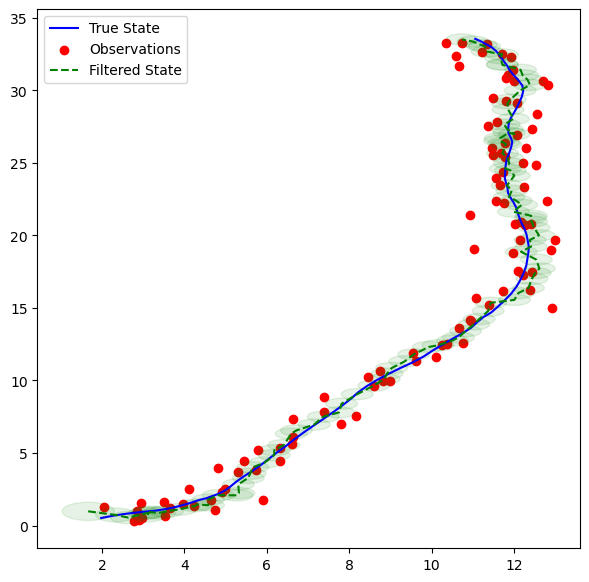

In [2]:
from state_space_practice.kalman import kalman_filter

filtered_mean, filtered_cov, true_marginal_log_likelihood = kalman_filter(
    init_mean=car_tracking_model.m0,
    init_cov=car_tracking_model.P0,
    obs=ys,
    transition_matrix=car_tracking_model.F,
    process_cov=car_tracking_model.Q,
    measurement_matrix=car_tracking_model.H,
    measurement_cov=car_tracking_model.R,
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(true_xs[:100, 0], true_xs[:100, 1], label="True State", color="b")
ax.scatter(*ys[:100].T, label="Observations", color="r")
for i in range(100):
    ax.add_patch(
        plt.Circle(
            filtered_mean[i, :2],
            np.sqrt(filtered_cov[i, :2, :2].diagonal().sum()),
            color="g",
            alpha=0.1,
        )
    )
ax.plot(
    filtered_mean[:100, 0], filtered_mean[:100, 1], label="Filtered State", color="g", linestyle="--"
)
_ = plt.legend()

Iteration 0: log-likelihood = -17958.28
Diff: 0.00
Iteration 1: log-likelihood = -17940.42
Diff: 17.86
Iteration 2: log-likelihood = -17940.05
Diff: 0.37
Converged at iteration 2 with log-likelihood = -17940.05


Text(0, 0.5, 'Log-likelihood')

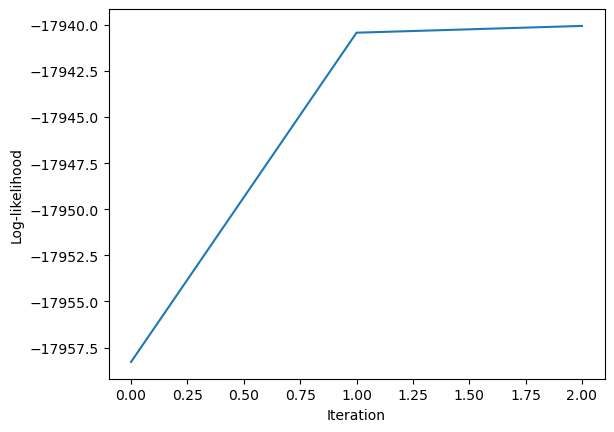

In [3]:
# estimate parameters

from state_space_practice.kalman import kalman_smoother, kalman_maximization_step
from state_space_practice.utils import check_converged


n_iter = 10
init_mean=car_tracking_model.m0
init_cov=car_tracking_model.P0
obs=ys
transition_matrix=car_tracking_model.F
process_cov=car_tracking_model.Q
measurement_matrix=car_tracking_model.H
measurement_cov=car_tracking_model.R

log_likelihoods = []
is_converged = False


for i in range(n_iter):
    # E-step
    smoother_mean, smoother_cov, smoother_cross_cov, marginal_log_likelihood = (
        kalman_smoother(
            init_mean=init_mean,
            init_cov=init_cov,
            obs=obs,
            transition_matrix=transition_matrix,
            process_cov=process_cov,
            measurement_matrix=measurement_matrix,
            measurement_cov=measurement_cov,
        )
    )
    print(f"Iteration {i}: log-likelihood = {marginal_log_likelihood:.2f}")
    log_likelihoods.append(marginal_log_likelihood)
    # M-step
    (
        transition_matrix,
        _,
        process_cov,
        measurement_cov,
        init_mean,
        init_cov,
    ) = kalman_maximization_step(
        obs=ys,
        smoother_mean=smoother_mean,
        smoother_cov=smoother_cov,
        smoother_cross_cov=smoother_cross_cov,
    )

    is_converged, is_increasing = check_converged(
        log_likelihoods[-1],
        log_likelihoods[-2] if len(log_likelihoods) > 1 else 0,
    )
    print(f"Diff: {log_likelihoods[-1] - log_likelihoods[-2] if len(log_likelihoods) > 1 else 0:.2f}")

    if is_converged:
        print(f"Converged at iteration {i} with log-likelihood = {log_likelihoods[-1]:.2f}")
        break

plt.plot(log_likelihoods)
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")

Iteration 0: log-likelihood = -123947893412.92
Diff: 0.00
Iteration 1: log-likelihood = -72512.60
Diff: 123947820900.33
Iteration 2: log-likelihood = -63220.26
Diff: 9292.34
Iteration 3: log-likelihood = -58803.14
Diff: 4417.12
Iteration 4: log-likelihood = -55179.23
Diff: 3623.91
Iteration 5: log-likelihood = -51683.85
Diff: 3495.38
Iteration 6: log-likelihood = -48271.89
Diff: 3411.97
Iteration 7: log-likelihood = -44986.11
Diff: 3285.77
Iteration 8: log-likelihood = -41913.84
Diff: 3072.28
Iteration 9: log-likelihood = -39188.37
Diff: 2725.46
Iteration 10: log-likelihood = -36961.23
Diff: 2227.14
Iteration 11: log-likelihood = -35323.92
Diff: 1637.32
Iteration 12: log-likelihood = -34236.14
Diff: 1087.78
Iteration 13: log-likelihood = -33554.26
Diff: 681.88
Iteration 14: log-likelihood = -33126.30
Diff: 427.96
Iteration 15: log-likelihood = -32846.33
Diff: 279.97
Iteration 16: log-likelihood = -32653.20
Diff: 193.13
Iteration 17: log-likelihood = -32513.29
Diff: 139.91
Iteration 18:

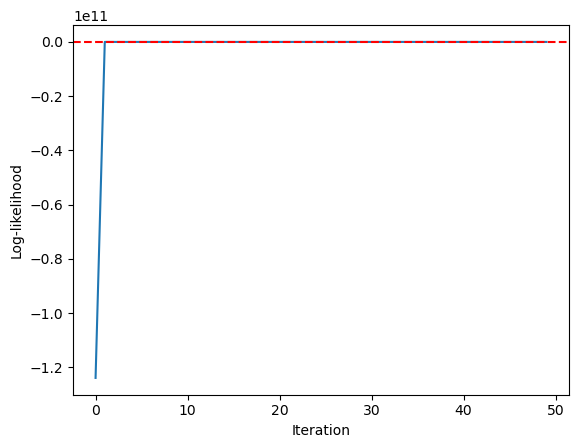

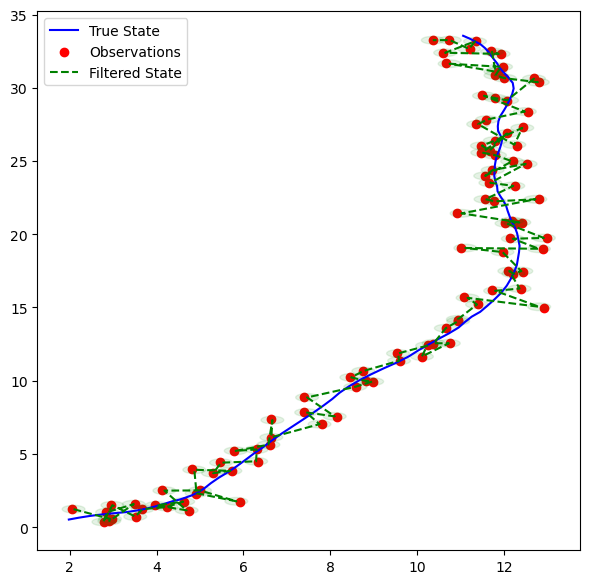

In [4]:
# estimate parameters

from state_space_practice.kalman import kalman_smoother, kalman_maximization_step
from state_space_practice.utils import check_converged


n_iter = 50
init_mean = np.zeros(4)
init_cov = np.eye(4)
obs = ys
transition_matrix = np.eye(4) * 0.9
process_cov = np.eye(4) * 0.1
measurement_matrix = car_tracking_model.H
measurement_cov = np.eye(2)

log_likelihoods = []
is_converged = False


for i in range(n_iter):
    # E-step
    smoother_mean, smoother_cov, smoother_cross_cov, marginal_log_likelihood = (
        kalman_smoother(
            init_mean=init_mean,
            init_cov=init_cov,
            obs=obs,
            transition_matrix=transition_matrix,
            process_cov=process_cov,
            measurement_matrix=measurement_matrix,
            measurement_cov=measurement_cov,
        )
    )
    print(f"Iteration {i}: log-likelihood = {marginal_log_likelihood:.2f}")
    log_likelihoods.append(marginal_log_likelihood)
    # M-step
    (
        transition_matrix,
        _,
        process_cov,
        measurement_cov,
        init_mean,
        init_cov,
    ) = kalman_maximization_step(
        obs=ys,
        smoother_mean=smoother_mean,
        smoother_cov=smoother_cov,
        smoother_cross_cov=smoother_cross_cov,
    )

    is_converged, is_increasing = check_converged(
        log_likelihoods[-1],
        log_likelihoods[-2] if len(log_likelihoods) > 1 else 0,
    )
    print(
        f"Diff: {log_likelihoods[-1] - log_likelihoods[-2] if len(log_likelihoods) > 1 else 0:.2f}"
    )

    if is_converged:
        print(
            f"Converged at iteration {i} with log-likelihood = {log_likelihoods[-1]:.2f}"
        )
        break

plt.plot(log_likelihoods)
plt.axhline(true_marginal_log_likelihood, color="r", linestyle="--")
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(true_xs[:100, 0], true_xs[:100, 1], label="True State", color="b")
ax.scatter(*ys[:100].T, label="Observations", color="r")
for i in range(100):
    ax.add_patch(
        plt.Circle(
            smoother_mean[i, :2],
            np.sqrt(smoother_cov[i, :2, :2].diagonal().sum()),
            color="g",
            alpha=0.1,
        )
    )
ax.plot(
    smoother_mean[:100, 0],
    smoother_mean[:100, 1],
    label="Filtered State",
    color="g",
    linestyle="--",
)
_ = plt.legend()

In [5]:
np.exp(0)

1.0